In [1]:
# USE KAIJU/KAIPY KERNEL
import os
import h5py
import pandas as pd
import numpy as np
import xarray as xr
import scipy.stats as sps
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.time import Time #For converting MJD to datetime
plt.style.use('~/plots/paper.mplstyle')
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapely

import kaipy.kaiViz as kv
import kaipy.kaiH5 as kh5
import kaipy.gamera.magsphere as msph
import kaipy.remix.remix as remix
import kaipy.kaiTools as ktools
import kaipy.supermage as smage

import ensemble_lib as el
import supermag_api as smapi #Acquired from https://supermag.jhuapl.edu/mag/lib/content/api/supermag-api.py

# Just trying out these colors, they ought to be changed in the future
r = '#BB3E03'
g = '#AE2012'
b = '#005F73'

/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/site-packages/bezpy/mt/io.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Calculate the GIC datasets from attenuated and non-attenuated datasets
mageDataPath = '/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high'
mageRunID = 'dptd-prime-high'
deltab_tag = 'deltab_lowres'
bezpyDataPath = '/glade/u/home/cobrien/ensemble-analysis/data/bezpy-data'
bezpyFilename = 'USA_impedance_gridded_45per_0.25x0.25-SP2.dat'
transmission_file = "transmission_line_objects.pkl"

model_sites_sorted, site_xys = el.load_bezpy_cache(bezpyDataPath, bezpyFilename)
transmission_df = el.get_transmission_lines(bezpyDataPath, transmission_file = transmission_file, site_xys = site_xys)
metadata_dict = {
    'model_sites_sorted' : model_sites_sorted,
    'site_xys' : site_xys,
    'transmission_df' : transmission_df,
}

/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


In [3]:
# Make the attenuated version of the MAGE data
data_high_xr = el.read_mage(os.path.join(mageDataPath,f"{mageRunID}.{deltab_tag}.h5"))
e_high_xr = xr.load_dataset(os.path.join(mageDataPath,"mage_data_nonatten.nc"))
mapping_high = el.create_impedance_mapping(model_sites_sorted, data_high_xr)
nlon = len(np.unique(data_high_xr['B']['longitude'])) # Number of longitudes in grid
nlat = len(np.unique(data_high_xr['B']['latitude']))
lon_freq = np.fft.fftfreq(nlon, d = 2)

n_freqs = [1, 2, 4, 6, 12] # Frequencies (180, 90, 45, 30, 15)
max_I = np.empty((3, len(n_freqs), len(data_high_xr.time)))
line_num = 6487
bnd_I = np.empty((3, len(n_freqs), len(data_high_xr.time))) # Current in the boundary waters station
xr_list = [] # Holds the attenuated deltab data (unattenuated is the new -1th, added at end)
#NOTE: xr_list[i] holds a deltab array with only frequency components UP TO AND INCLUDING the ith frequency
for i, n_freq in enumerate(n_freqs):
    print(f"Processing Frequency {i+1} of {len(n_freqs)}")
    data_xr_copy = xr.load_dataset(
        os.path.join(mageDataPath,"deltab_freq", f"{mageRunID}.{deltab_tag}_{lon_freq[n_freq]**(-1)/2}.nc") # Pull the saved array from meso_degrees.py
    )
    xr_list.append(data_xr_copy)
    e_xr = el.calc_e(mapping_high, data_xr_copy, model_sites_sorted) # Add E into non-attenuated dataset
    e_xr = el.calc_voltages(transmission_df, e_xr)

    max_I[0, i, :] = np.max(np.abs(e_xr['I']), axis = 1).values # -1 is because n_freq indexes from 1
    bnd_I[0, i, :] = e_xr['I'][:, line_num].values
xr_list.append(data_high_xr)

data_mean_xr = el.read_mage(os.path.join('/glade/derecho/scratch/cobrien/doctor-patient-day-prime',f"{'dptd-prime'}.{deltab_tag}.h5"))
e_mean_xr = xr.load_dataset(os.path.join('/glade/derecho/scratch/cobrien/doctor-patient-day-prime',"mage_data_nonatten.nc"))
mapping_mean = el.create_impedance_mapping(model_sites_sorted, data_mean_xr)
#NOTE: xr_list[i] holds a deltab array with only frequency components UP TO AND INCLUDING the ith frequency
for i, n_freq in enumerate(n_freqs):
    print(f"Processing Frequency {i+1} of {len(n_freqs)}")
    data_xr_copy = xr.load_dataset(
        os.path.join('/glade/derecho/scratch/cobrien/doctor-patient-day-prime',"deltab_freq", f"{'dptd-prime'}.{deltab_tag}_{lon_freq[n_freq]**(-1)/2}.nc") # Pull the saved array from meso_degrees.py
    )
    xr_list.append(data_xr_copy)
    e_xr = el.calc_e(mapping_mean, data_xr_copy, model_sites_sorted) # Add E into non-attenuated dataset
    e_xr = el.calc_voltages(transmission_df, e_xr)

    max_I[1, i, :] = np.max(np.abs(e_xr['I']), axis = 1).values # -1 is because n_freq indexes from 1
    bnd_I[1, i, :] = e_xr['I'][:, line_num].values
xr_list.append(data_mean_xr)

data_low_xr = el.read_mage(os.path.join('/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low',f"{'dptd-prime-low'}.{deltab_tag}.h5"))
e_low_xr = xr.load_dataset(os.path.join('/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low',"mage_data_nonatten.nc"))
mapping_low = el.create_impedance_mapping(model_sites_sorted, data_low_xr)
#NOTE: xr_list[i] holds a deltab array with only frequency components UP TO AND INCLUDING the ith frequency
for i, n_freq in enumerate(n_freqs):
    print(f"Processing Frequency {i+1} of {len(n_freqs)}")
    data_xr_copy = xr.load_dataset(
        os.path.join('/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low',"deltab_freq", f"{'dptd-prime-low'}.{deltab_tag}_{lon_freq[n_freq]**(-1)/2}.nc") # Pull the saved array from meso_degrees.py
    )
    xr_list.append(data_xr_copy)
    e_xr = el.calc_e(mapping_low, data_xr_copy, model_sites_sorted) # Add E into non-attenuated dataset
    e_xr = el.calc_voltages(transmission_df, e_xr)

    max_I[2, i, :] = np.max(np.abs(e_xr['I']), axis = 1).values # -1 is because n_freq indexes from 1
    bnd_I[2, i, :] = e_xr['I'][:, line_num].values
xr_list.append(data_low_xr)

Processing Frequency 1 of 5
Processing Frequency 2 of 5
Processing Frequency 3 of 5
Processing Frequency 4 of 5
Processing Frequency 5 of 5
Processing Frequency 1 of 5
Processing Frequency 2 of 5
Processing Frequency 3 of 5
Processing Frequency 4 of 5
Processing Frequency 5 of 5
Processing Frequency 1 of 5
Processing Frequency 2 of 5
Processing Frequency 3 of 5
Processing Frequency 4 of 5
Processing Frequency 5 of 5


/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/site-packages/xarray/core/dataarray.py:6446: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmax(dim, axis, keep_attrs, skipna)


Peak Occurs at Index <xarray.DataArray 'I' ()> Size: 8B
array(588)


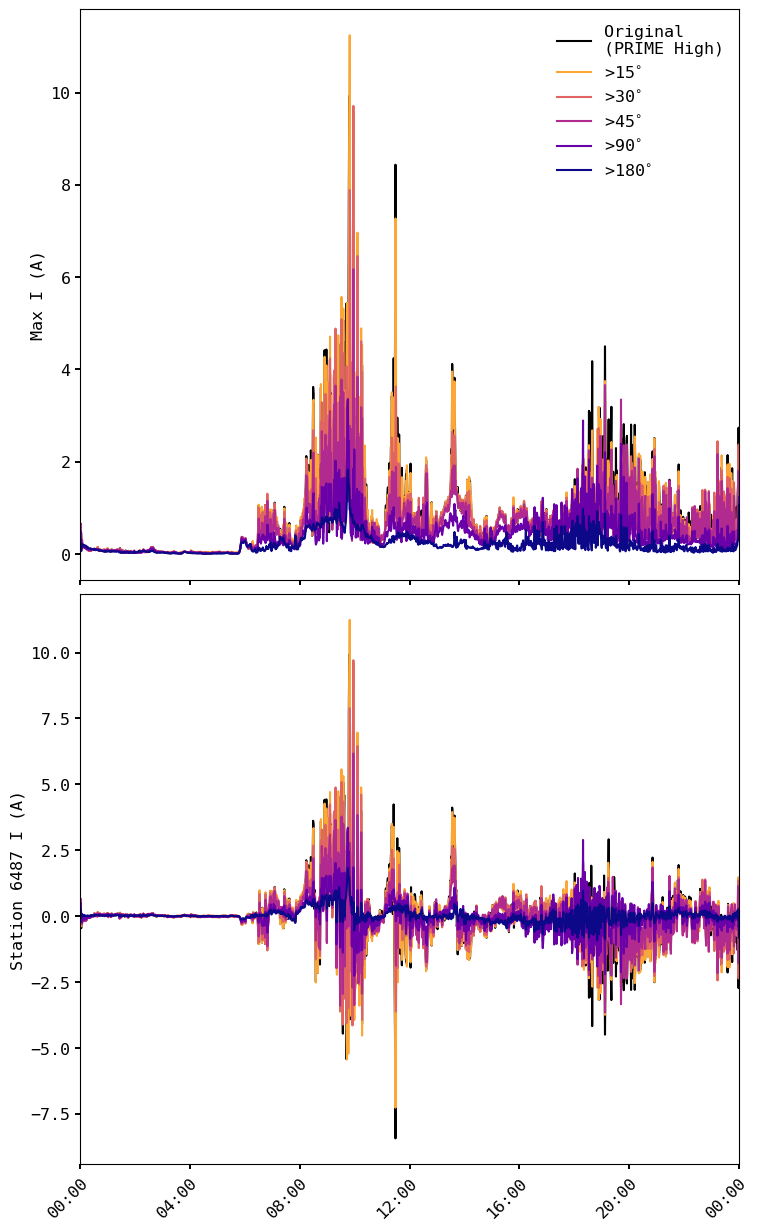

In [4]:
fig, ax = plt.subplots(2, 1, figsize = (8.5, 15), sharex = True)
plt.subplots_adjust(hspace = 0.025)

# Max GIC in all lines
ax[0].plot(e_high_xr['time'], np.max(np.abs(e_high_xr['I']), axis = 1), color = 'k', label = 'Original\n(PRIME High)')
for i, n_freq in reversed(list(enumerate(n_freqs))): # Just select a few representative whole-number spatial frequencies (15, 30, 60, 90, 180)
    ax[0].plot(e_high_xr['time'], max_I[0, i, :], color = plt.colormaps['plasma'](i/len(n_freqs)), label = f'>{lon_freq[n_freq]**(-1)/2:.0f}'+r'$^{\circ}$')
ax[0].set_ylabel(f"Max I (A)")
ax[0].legend()

# GICs in one particular line (that experiences the maximum current in the above plot)
line_num = 6487
ax[1].plot(e_high_xr['time'], e_high_xr['I'][:, line_num], color = 'k', label = 'Original\n(PRIME High)')
for i, n_freq in reversed(list(enumerate(n_freqs))): # Just select a few representative whole-number spatial frequencies (15, 30, 60, 90, 180)
    ax[1].plot(e_high_xr['time'], bnd_I[0, i, :], color = plt.colormaps['plasma'](i/len(n_freqs)), label = f'>{lon_freq[n_freq]**(-1)/2:.0f}'+r'$^{\circ}$')
ax[1].set_ylabel(f"Station {line_num} I (A)")

bounds = [pd.to_datetime('2013-03-17 00:00:00+0000'), pd.to_datetime('2013-03-18 00:00:00+0000')]
ax[-1].set_xlim(bounds[0], bounds[1])
n_ticks = 7
ax[-1].set_xticks(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks))
_ = ax[-1].set_xticklabels(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
print(f"Peak Occurs at Index {np.max(np.abs(e_high_xr['I']), axis = 1).argmax()}")

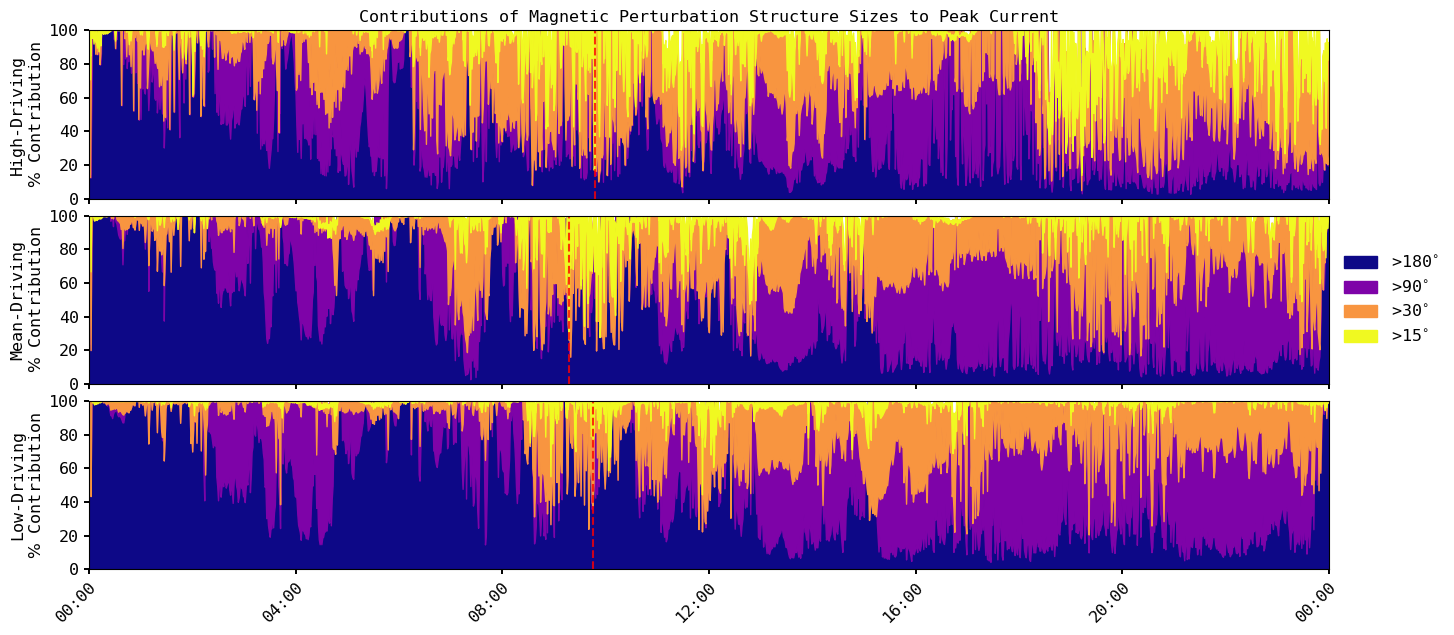

In [5]:
# Scale each contribution to the original, fill between

fig, ax = plt.subplots(3, 1, figsize = (16, 7), height_ratios=(1, 1, 1), sharex=True)
plt.subplots_adjust(hspace = 0.1)

# Max GIC in all lines
prior = np.zeros(len(e_high_xr['time']))
for i, n_freq in enumerate(n_freqs):
    if i == 2:
        continue
    ax[0].fill_between(e_high_xr['time'], prior, 100*max_I[0, i, :]/np.max(np.abs(e_high_xr['I']), axis = 1), color = plt.colormaps['plasma'](i/(len(n_freqs)-1)), label = f'>{lon_freq[n_freq]**(-1)/2:.0f}'+r'$^{\circ}$')
    prior = 100*max_I[0, i, :]/np.max(np.abs(e_high_xr['I']), axis = 1)
ax[0].axvline(e_high_xr['time'][588].data, ls = '--', color = 'r', alpha = 0.8)
ax[0].set_ylabel(f"High-Driving\n"+r"$\%$ Contribution")
ax[0].set_ylim(0, 100)

prior = np.zeros(len(e_mean_xr['time']))
for i, n_freq in enumerate(n_freqs):
    if i == 2:
        continue
    ax[1].fill_between(e_mean_xr['time'], prior, 100*max_I[1, i, :]/np.max(np.abs(e_mean_xr['I']), axis = 1), color = plt.colormaps['plasma'](i/(len(n_freqs)-1)), label = f'>{lon_freq[n_freq]**(-1)/2:.0f}'+r'$^{\circ}$')
    prior = 100*max_I[1, i, :]/np.max(np.abs(e_mean_xr['I']), axis = 1)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].axvline(e_high_xr['time'][558].data, ls = '--', color = 'r', alpha = 0.8)
ax[1].set_ylabel(f"Mean-Driving\n"+r"$\%$ Contribution")
ax[1].set_ylim(0, 100)

prior = np.zeros(len(e_low_xr['time']))
for i, n_freq in enumerate(n_freqs):
    if i == 2:
        continue
    ax[2].fill_between(e_low_xr['time'], prior, 100*max_I[2, i, :]/np.max(np.abs(e_low_xr['I']), axis = 1), color = plt.colormaps['plasma'](i/(len(n_freqs)-1)), label = f'>{lon_freq[n_freq]**(-1)/2:.0f}'+r'$^{\circ}$')
    prior = 100*max_I[2, i, :]/np.max(np.abs(e_low_xr['I']), axis = 1)
ax[2].axvline(e_high_xr['time'][585].data, ls = '--', color = 'r', alpha = 0.8)
ax[2].set_ylabel(f"Low-Driving\n"+r"$\%$ Contribution")
ax[2].set_ylim(0, 100)

ax[0].set_title('Contributions of Magnetic Perturbation Structure Sizes to Peak Current')
bounds = [pd.to_datetime('2013-03-17 00:00:00+0000'), pd.to_datetime('2013-03-18 00:00:00+0000')]
ax[-1].set_xlim(bounds[0], bounds[1])
n_ticks = 7
ax[-1].set_xticks(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks))
_ = ax[-1].set_xticklabels(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/scale_comp.pdf', bbox_inches = 'tight')

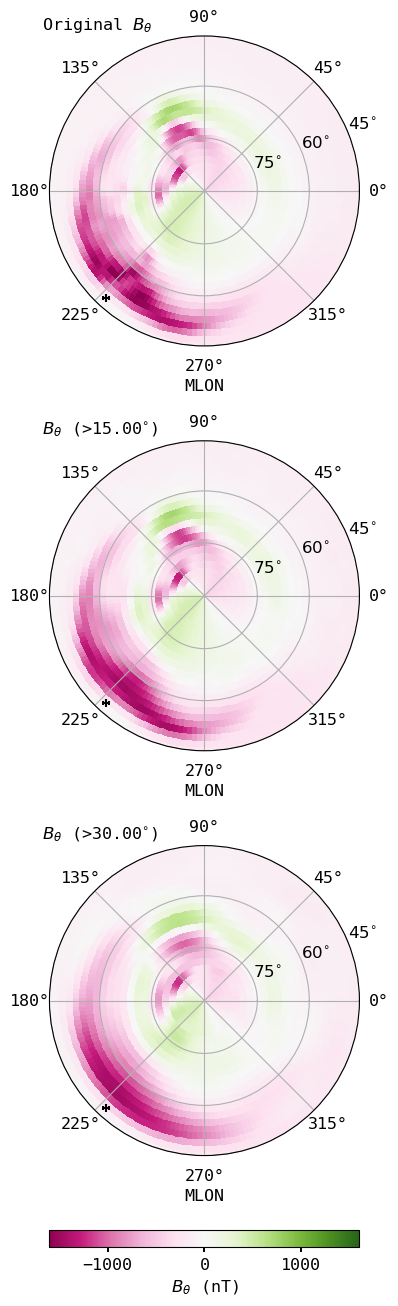

In [10]:
plot_t = np.unique(np.deg2rad(np.where(xr_list[-1]["longitude"] < 0, xr_list[-1]["longitude"] + 360, xr_list[-1]["longitude"])))# Precompute the plot coordinates
plot_phi = np.unique(xr_list[-1]["latitude"])
plot_r = np.sin(np.deg2rad(90 - plot_phi)/2)

plot_T, plot_R = np.meshgrid(plot_t, plot_r)

t_ind = 588 # Index to plot (high sim peak)
fig = plt.figure(figsize=(4, 16)) 
gs = mpl.gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1, 0.05])
ax0 = plt.subplot(gs[0], projection = 'polar')
ax1 = plt.subplot(gs[1], projection = 'polar')
ax2 = plt.subplot(gs[2], projection = 'polar')
cax = plt.subplot(gs[3])
ax = [ax0, ax1, ax2]

lat_ticks = np.array([15, 30, 45])
lim_lat = 45
ex_position = (274.6, 90 - 48) # Lon/Lat corresponding to the boundary waters station
textpos = (np.deg2rad(135), np.sin(np.deg2rad(69/2)))
mlon_shift = np.deg2rad(ex_position[0] - 227.5) # Shift from GEO longitude to magnetic longitude

i = len(n_freqs) # The original is appended after each set of frequencies
im0 = ax[0].pcolormesh(plot_T - mlon_shift, plot_R, xr_list[i]["B"][t_ind,:,1].data.reshape(180, 90).T, vmin = -1600, vmax = 1600, cmap = 'PiYG', shading = 'nearest')
ax[0].set_aspect('equal')
ax[0].set_xlabel('MLON')
ax[0].set_rlim(0, np.sin(np.deg2rad(lim_lat/2)))
ax[0].set_rticks(np.sin(np.deg2rad(lat_ticks/2)), labels = r'$' + (90 - lat_ticks).astype(str) + r'^{\circ}$')
ax[0].text(textpos[0], textpos[1], r'Original $B_{\theta}$', fontsize = 'large')
ax[0].scatter(np.deg2rad(ex_position[0]) - mlon_shift, np.sin(np.deg2rad(ex_position[1]/2)), color = 'k', marker = '+')

i = 4
im0 = ax[1].pcolormesh(plot_T - mlon_shift, plot_R, xr_list[i]["B"][t_ind,:,1].data.reshape(180, 90).T, vmin = -1600, vmax = 1600, cmap = 'PiYG', shading = 'nearest')
ax[1].set_aspect('equal')
ax[1].set_xlabel('MLON')
ax[1].set_rlim(0, np.sin(np.deg2rad(lim_lat/2)))
ax[1].set_rticks(np.sin(np.deg2rad(lat_ticks/2)), labels = r'$' + (90 - lat_ticks).astype(str) + r'^{\circ}$')
ax[1].text(textpos[0], textpos[1], r'$B_{\theta}$ (' + f'>{lon_freq[n_freqs[i]]**(-1)/2:.2f}'+r'$^{\circ}$)', fontsize = 'large')
ax[1].scatter(np.deg2rad(ex_position[0]) - mlon_shift, np.sin(np.deg2rad(ex_position[1]/2)), color = 'k', marker = '+')

i = 3
im0 = ax[2].pcolormesh(plot_T - mlon_shift, plot_R, xr_list[i]["B"][t_ind,:,1].data.reshape(180, 90).T, vmin = -1600, vmax = 1600, cmap = 'PiYG', shading = 'nearest')
ax[2].set_aspect('equal')
ax[2].set_xlabel('MLON')
ax[2].set_rlim(0, np.sin(np.deg2rad(lim_lat/2)))
ax[2].set_rticks(np.sin(np.deg2rad(lat_ticks/2)), labels = r'$' + (90 - lat_ticks).astype(str) + r'^{\circ}$')
ax[2].text(textpos[0], textpos[1], r'$B_{\theta}$ (' + f'>{lon_freq[n_freqs[i]]**(-1)/2:.2f}'+r'$^{\circ}$)', fontsize = 'large')
ax[2].scatter(np.deg2rad(ex_position[0]) - mlon_shift, np.sin(np.deg2rad(ex_position[1]/2)), color = 'k', marker = '+')

plt.colorbar(im0, cax = cax, label = r"$B_{\theta}$ (nT)", orientation = 'horizontal')

# plt.savefig(f"plots/combo_db_figs/bt_map_high_polar.png", dpi = 300, bbox_inches = 'tight')

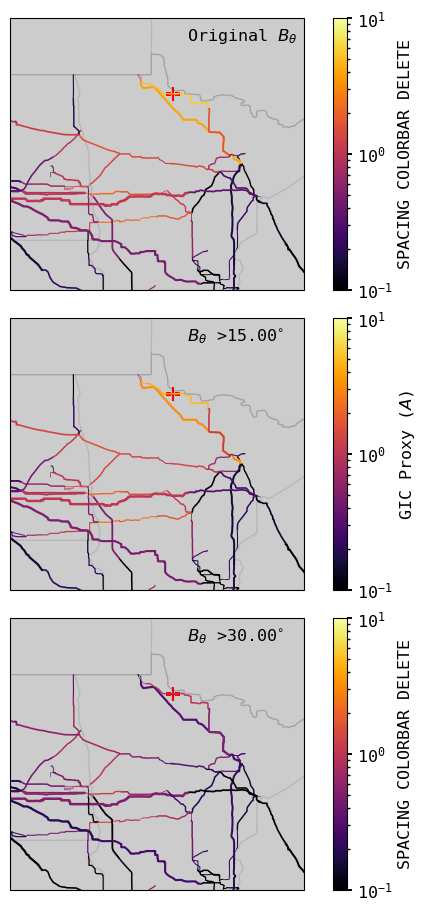

In [11]:
# Make GIC maps for several different feature scale sizes
xr_inds = [len(n_freqs), 4, 3]
e_xr_0 = el.calc_e(mapping_high, xr_list[xr_inds[0]], model_sites_sorted)
e_xr_0 = el.calc_voltages(transmission_df, e_xr_0)
e_xr_1 = el.calc_e(mapping_high, xr_list[xr_inds[1]], model_sites_sorted)
e_xr_1 = el.calc_voltages(transmission_df, e_xr_1)
e_xr_2 = el.calc_e(mapping_high, xr_list[xr_inds[2]], model_sites_sorted)
e_xr_2 = el.calc_voltages(transmission_df, e_xr_2)


feature_dict = el.prep_plot_objects() #Intializes countries, oceans, state borders, etc.
# Create the plot bounds
# bbox = (np.min(metadata_dict['site_xys'][:, 0]), np.max(metadata_dict['site_xys'][:, 0]), # Use this for full CONUS plot
#         np.min(metadata_dict['site_xys'][:, 1]), np.max(metadata_dict['site_xys'][:, 1]))
bbox = (-99, -91,
        45, 50)
# Get the impedance grid
grid = el.init_grid(metadata_dict['site_xys'])

projection = ccrs.Mercator() #Plot projection style
fig, (ax0, ax1, ax2) = plt.subplots(figsize=(7, 9), nrows=3, height_ratios=[1,1,1], constrained_layout=True, subplot_kw=dict(projection=projection))

for ax in [ax0, ax1, ax2]:
    el.setup_axes(ax, feature_dict=feature_dict, bbox = bbox, statealpha = 0.1, countryalpha = 0.1, oceancolor = 'gray')

t0 = 588
t1 = 588
t2 = 588
# title = plt.suptitle(str(xr_list[0].time[t0].data))
line_num = 6487
ex_position = metadata_dict['transmission_df']['geometry'].iloc[line_num].coords[0]

I0 = el.plot_quantity(ax0, e_xr_0, metadata_dict['transmission_df'],
                          grid, t = t0, quantity = "I",
                          I_norm = mpl.colors.LogNorm(1e-1, 1e1), I_cmap = mpl.colormaps["inferno"]) # _coll for collection
ax0.text(-94.2, 49.6, r'Original $B_{\theta}$', fontsize = 'large', transform = ccrs.PlateCarree())
ax0.scatter(ex_position[0], ex_position[1], color = 'r', transform = ccrs.PlateCarree(), marker = '+', s = 90)
I1 = el.plot_quantity(ax1, e_xr_1, metadata_dict['transmission_df'],
                          grid, t = t1, quantity = "I",
                          I_norm = mpl.colors.LogNorm(1e-1, 1e1), I_cmap = mpl.colormaps["inferno"]) # _coll for collection
ax1.text(-94.2, 49.6, r'$B_{\theta}$ '+f'>{lon_freq[n_freqs[xr_inds[1]]]**(-1)/2:.2f}'+r'$^{\circ}$', fontsize = 'large', transform = ccrs.PlateCarree())
ax1.scatter(ex_position[0], ex_position[1], color = 'r', transform = ccrs.PlateCarree(), marker = '+', s = 90)
I2 = el.plot_quantity(ax2, e_xr_2, metadata_dict['transmission_df'],
                          grid, t = t2, quantity = "I",
                          I_norm = mpl.colors.LogNorm(1e-1, 1e1), I_cmap = mpl.colormaps["inferno"]) # _coll for collection
ax2.text(-94.2, 49.6, r'$B_{\theta}$ '+f'>{lon_freq[n_freqs[xr_inds[2]]]**(-1)/2:.2f}'+r'$^{\circ}$', fontsize = 'large', transform = ccrs.PlateCarree())
ax2.scatter(ex_position[0], ex_position[1], color = 'r', transform = ccrs.PlateCarree(), marker = '+', s = 90)

cbar0 = fig.colorbar(ax = ax0, mappable = I0, orientation = 'vertical')
cbar0.set_label('SPACING COLORBAR DELETE')
cbar1 = fig.colorbar(ax = ax1, mappable = I1, orientation = 'vertical')
cbar1.set_label('GIC Proxy ($A$)')
cbar2 = fig.colorbar(ax = ax2, mappable = I2, orientation = 'vertical')
cbar2.set_label('SPACING COLORBAR DELETE')

fig.canvas.draw()
fig.set_constrained_layout(False)
# plt.savefig('plots/combo_db_figs/GIC_comparison_high.png', bbox_inches = 'tight', dpi = 300)

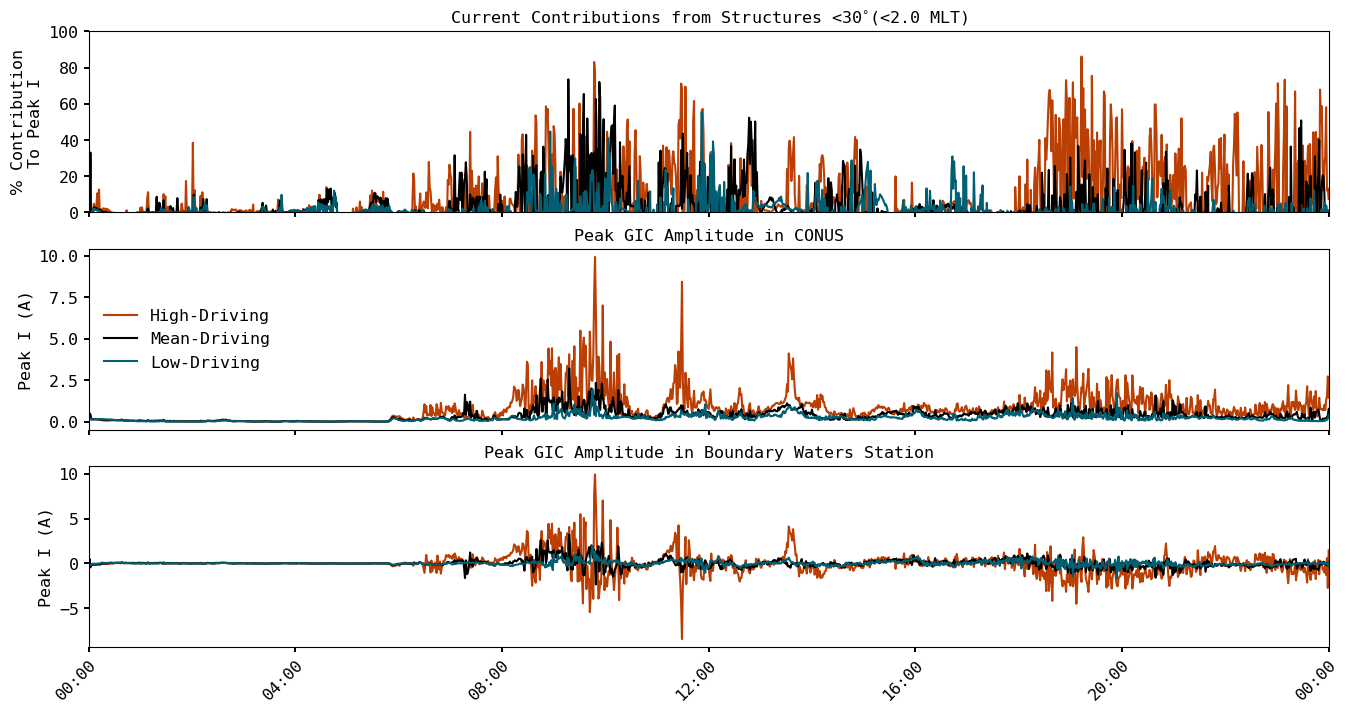

In [12]:
# Plt the current contributions from just the mesoscale structures in each sim, the peak GICs in conus in each sim, and the Boundary Waters station in each sim

fig, ax = plt.subplots(3, 1, figsize = (16, 8), sharex = True)

# Max GIC in all lines
prior = np.zeros(len(e_high_xr['time']))
i = 3 # Which frequency? Check def of n_freqs
bin_width = '60min'
time_bins = pd.date_range(e_high_xr['time'][0].values, e_high_xr['time'][-1].values+pd.Timedelta(minutes=120), freq = bin_width).to_numpy().astype(float)
plot_time = pd.date_range(e_high_xr['time'][0].values, e_high_xr['time'][-1].values+pd.Timedelta(minutes=120), freq = bin_width)[:-1]
frac_high, _, _ = sps.binned_statistic(e_high_xr['time'].astype(float).values, 100*(1 - max_I[0, i, :]/np.max(np.abs(e_high_xr['I']), axis = 1)), statistic = 'mean', bins = time_bins)
frac_mean, _, _ = sps.binned_statistic(e_mean_xr['time'].astype(float).values, 100*(1 - max_I[1, i, :]/np.max(np.abs(e_mean_xr['I']), axis = 1)), statistic = 'mean', bins = time_bins)
frac_low, _, _ = sps.binned_statistic(e_low_xr['time'].astype(float).values, 100*(1 - max_I[2, i, :]/np.max(np.abs(e_low_xr['I']), axis = 1)), statistic = 'mean', bins = time_bins)

ax[0].plot(e_high_xr['time'], 100*(1 - max_I[0, i, :]/np.max(np.abs(e_high_xr['I']), axis = 1)), color = r, label = f'High-Driving')
ax[0].plot(e_mean_xr['time'], 100*(1 - max_I[1, i, :]/np.max(np.abs(e_mean_xr['I']), axis = 1)), color = 'k', label = f'Mean-Driving')
ax[0].plot(e_low_xr['time'], 100*(1 - max_I[2, i, :]/np.max(np.abs(e_low_xr['I']), axis = 1)), color = b, label = f'Low-Driving')
ax[0].set_ylabel(r"$\%$ Contribution"+"\nTo Peak I")
ax[0].set_title(f'Current Contributions from Structures <{lon_freq[n_freqs[i]]**(-1)/2:.0f}'+r'$^{\circ}$' + f'(<{lon_freq[n_freqs[i]]**(-1)/2/15:.1f} MLT)')
ax[0].set_ylim(0, 100)

ax[1].plot(e_high_xr['time'], np.max(np.abs(e_high_xr['I']), axis = 1), color = r, label = f'High-Driving')
ax[1].plot(e_mean_xr['time'], np.max(np.abs(e_mean_xr['I']), axis = 1), color = 'k', label = f'Mean-Driving')
ax[1].plot(e_low_xr['time'], np.max(np.abs(e_low_xr['I']), axis = 1), color = b, label = f'Low-Driving')
ax[1].legend(loc='center left')
ax[1].set_ylabel(r"Peak I (A)")
ax[1].set_title(f'Peak GIC Amplitude in CONUS')

line_num = 6487
ax[2].plot(e_high_xr['time'], e_high_xr['I'][:, line_num], color = r, label = f'High-Driving')
ax[2].plot(e_mean_xr['time'], e_mean_xr['I'][:, line_num], color = 'k', label = f'Mean-Driving')
ax[2].plot(e_low_xr['time'], e_low_xr['I'][:, line_num], color = b, label = f'Low-Driving')
ax[2].set_ylabel(r"Peak I (A)")
ax[2].set_title(f'Peak GIC Amplitude in Boundary Waters Station')

bounds = [pd.to_datetime('2013-03-17 00:00:00+0000'), pd.to_datetime('2013-03-18 00:00:00+0000')]
ax[-1].set_xlim(bounds[0], bounds[1])
n_ticks = 7
ax[-1].set_xticks(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks))
_ = ax[-1].set_xticklabels(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/scale_comp_lines.pdf', bbox_inches = 'tight')